In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

RAW = "../data/raw/"

# --- leitura e limpeza (mesmo padrão do merge_datasets.py) ---
ncm_raw = pd.read_csv(
    RAW + "comexstat_ncm_santos_2021-09_10.csv",
    sep=";",
    encoding="utf-8-sig",
)
for coluna in ncm_raw.columns:
    # checa "não numérico" em vez de "dtype == object": no pandas >= 2.x com a
    # opção de string dtype (e default no pandas 3.x), colunas de texto não são
    # mais "object" — usar só "== object" faz esse loop silenciosamente não
    # limpar nada e deixar sujeira de \r escondida no meio do texto
    if not pd.api.types.is_numeric_dtype(ncm_raw[coluna]):
        ncm_raw[coluna] = ncm_raw[coluna].astype(str).str.strip().str.replace("\r", "", regex=False)
ncm_raw.columns = [c.strip() for c in ncm_raw.columns]

ncm_raw["ano"] = ncm_raw["Ano"].astype(int)
ncm_raw["mes"] = ncm_raw["M\u00eas"].str.extract(r"^(\d+)").astype(int)
ncm_raw["ncm"] = ncm_raw["C\u00f3digo NCM"].astype(str).str.zfill(8)
ncm_raw["capitulo"] = ncm_raw["ncm"].str[:2]
ncm_raw["descricao"] = ncm_raw["Descri\u00e7\u00e3o NCM"]
ncm_raw["fob"] = ncm_raw["Valor US$ FOB"].astype(float)
ncm_raw["kg"] = ncm_raw["Quilograma L\u00edquido"].astype(float)

meses_nome = {9: "set/2021", 10: "out/2021"}
ncm_raw["mes_nome"] = ncm_raw["mes"].map(meses_nome)

ncm_raw[["ano", "mes_nome", "ncm", "descricao", "fob", "kg", "capitulo"]].head()


,ano,mes_nome,ncm,descricao,fob,kg,capitulo
0,2021,out/2021,02023000,"Carnes desossadas de bovino, congeladas",152003.0,1841.0,02
1,2021,out/2021,02101100,"Pernas/pás/pedaços, de suíno, não desossados, ...",483513.0,25788.0,02
2,2021,out/2021,02101200,"Barrigas e peitos, entremeados, de suíno, salg...",4518.0,795.0,02
3,2021,out/2021,02101900,"Outras carnes de suíno, salgadas ou em salmour...",987294.0,108782.0,02
4,2021,out/2021,03035400,"Cavalinhas (Scomber scombrus, Scomber australa...",63480.0,54000.0,03


In [2]:
display(Markdown(
    "## Detalhamento por produto \u2014 set/out de 2021\n\n"
    "No notebook `01_eda_painel_2015_2025`, o boxplot de `importa\u00e7\u00e3o_kg` apontou "
    "set/2021 e out/2021 como os \u00fanicos meses at\u00edpicos entre as vari\u00e1veis de "
    "com\u00e9rcio exterior \u2014 na verdade, os dois maiores volumes de importa\u00e7\u00e3o (em kg) "
    "de toda a s\u00e9rie 2015\u20132025. O c\u00e2mbio estava historicamente alto nesses meses "
    "(acima do Q3), o que a princ\u00edpio pareceria desestimular importa\u00e7\u00e3o, mas o "
    "volume f\u00edsico foi recorde. O notebook 01 s\u00f3 olhou peso agregado e ficou com uma "
    "pergunta em aberto: o pre\u00e7o m\u00e9dio impl\u00edcito por kg (fob/kg) desses meses "
    "tamb\u00e9m estava baixo, sugerindo carga de menor valor agregado \u2014 t\u00edpico de "
    "commodity/insumo agr\u00edcola \u2014 mesmo com o gasto total (fob) subindo?\n\n"
    "Esse notebook usa o detalhamento por NCM (Comex Stat) desses dois meses "
    "espec\u00edficos pra checar essa hip\u00f3tese com dado real de produto **e de pre\u00e7o**, "
    "em vez de infer\u00eancia indireta \u2014 as duas \u00faltimas c\u00e9lulas calculam o "
    "fob/kg de verdade."
))


## Detalhamento por produto — set/out de 2021

No notebook `01_eda_painel_2015_2025`, o boxplot de `importação_kg` apontou set/2021 e out/2021 como os únicos meses atípicos entre as variáveis de comércio exterior — na verdade, os dois maiores volumes de importação (em kg) de toda a série 2015–2025. O câmbio estava historicamente alto nesses meses (acima do Q3), o que a princípio pareceria desestimular importação, mas o volume físico foi recorde. O notebook 01 só olhou peso agregado e ficou com uma pergunta em aberto: o preço médio implícito por kg (fob/kg) desses meses também estava baixo, sugerindo carga de menor valor agregado — típico de commodity/insumo agrícola — mesmo com o gasto total (fob) subindo?

Esse notebook usa o detalhamento por NCM (Comex Stat) desses dois meses específicos pra checar essa hipótese com dado real de produto **e de preço**, em vez de inferência indireta — as duas últimas células calculam o fob/kg de verdade.

In [3]:
validacao = ncm_raw.groupby("mes_nome")[["fob", "kg"]].sum()

display(Markdown("### Confer\u00eancia: os totais batem com o painel?"))
display(validacao.style.format("{:,.0f}"))
display(Markdown(
    "Os totais de `fob` e `kg` agregados aqui batem exatamente com "
    "`importa\u00e7\u00e3o_fob` e `importa\u00e7\u00e3o_kg` do painel pra set e out/2021 \u2014 "
    "confirma que esse recorte de NCM \u00e9 o mesmo universo de carga, s\u00f3 "
    "aberto por produto."
))


### Conferência: os totais batem com o painel?

,fob,kg
mes_nome,,
out/2021,"5,472,646,856","3,355,031,185"
set/2021,"5,971,522,567","3,405,496,783"


Os totais de `fob` e `kg` agregados aqui batem exatamente com `importação_fob` e `importação_kg` do painel pra set e out/2021 — confirma que esse recorte de NCM é o mesmo universo de carga, só aberto por produto.

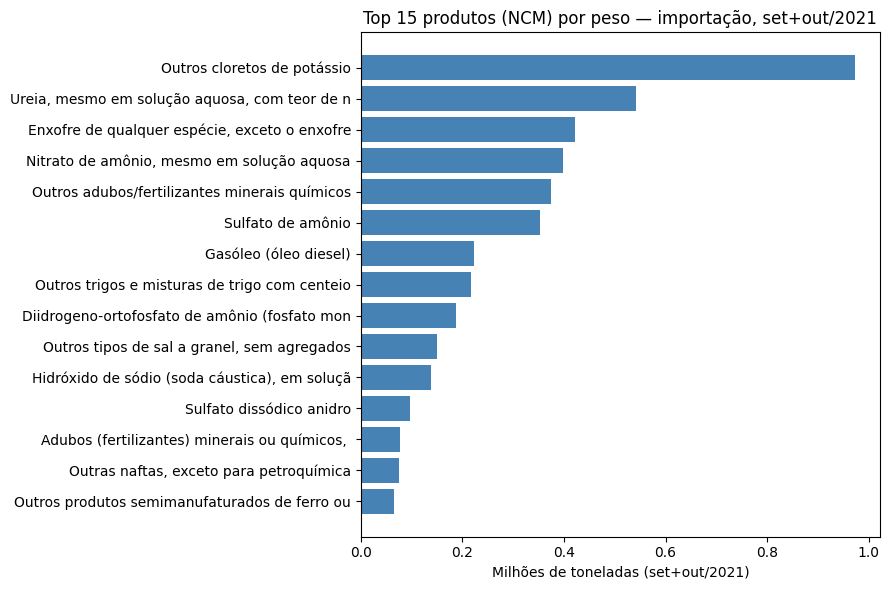

Esses 15 produtos sozinhos respondem por **63.6%** do peso total importado nos dois meses (de 6176 NCMs diferentes que aparecem no recorte).

In [4]:
top_n = 15
top_ncm = (
    ncm_raw.groupby(["ncm", "descricao"])["kg"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .reset_index()
)
top_ncm["kg_mi_t"] = top_ncm["kg"] / 1000 / 1e6  # peso em milh\u00f5es de toneladas

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_ncm["descricao"].str.slice(0, 45)[::-1], top_ncm["kg_mi_t"][::-1], color="steelblue")
ax.set_xlabel("Milh\u00f5es de toneladas (set+out/2021)")
ax.set_title(f"Top {top_n} produtos (NCM) por peso \u2014 importa\u00e7\u00e3o, set+out/2021")
plt.tight_layout()
plt.show()

pct_top = top_ncm["kg"].sum() / ncm_raw["kg"].sum() * 100
display(Markdown(
    f"Esses {top_n} produtos sozinhos respondem por **{pct_top:.1f}%** do peso total "
    f"importado nos dois meses (de {ncm_raw['ncm'].nunique()} NCMs diferentes que "
    "aparecem no recorte)."
))


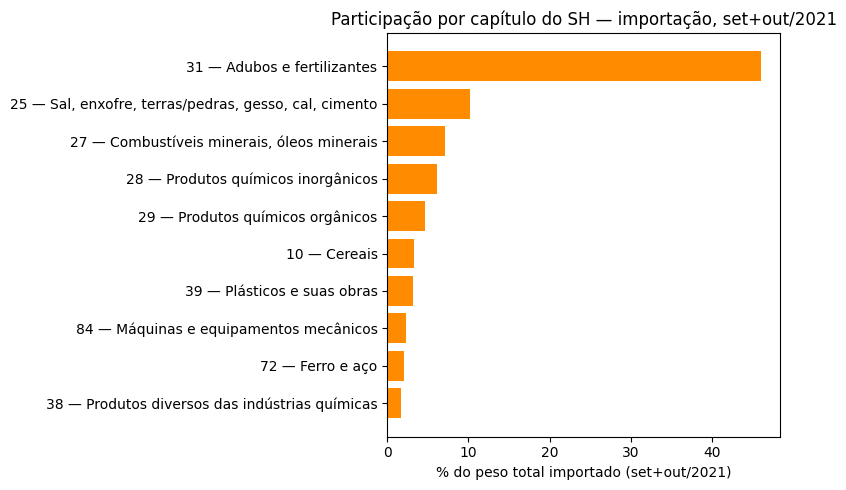

Sozinho, o capítulo **31 (adubos e fertilizantes)** responde por **46.0%** do peso importado nos dois meses. Somando os capítulos ligados à cadeia de fertilizante/insumo mineral (31 — adubos, 25 — enxofre/sal, 28 — químicos inorgânicos como soda cáustica), chega a **62.4%** do volume total.

Isso já explica o recorde de **peso**: não veio de bens manufaturados, e sim de uma concentração muito forte em fertilizante e seus insumos, puxada pela safra de verão 2021/22 (soja/milho), que precisa do insumo no chão antes do plantio independentemente do câmbio. Mas isso ainda é inferência sobre **preço** — fertilizante costuma ser barato por kg, mas não calculamos isso ainda. As próximas células fazem essa conta.

In [5]:
nomes_capitulo = {
    "31": "Adubos e fertilizantes",
    "25": "Sal, enxofre, terras/pedras, gesso, cal, cimento",
    "27": "Combust\u00edveis minerais, \u00f3leos minerais",
    "28": "Produtos qu\u00edmicos inorg\u00e2nicos",
    "29": "Produtos qu\u00edmicos org\u00e2nicos",
    "10": "Cereais",
    "39": "Pl\u00e1sticos e suas obras",
    "84": "M\u00e1quinas e equipamentos mec\u00e2nicos",
    "72": "Ferro e a\u00e7o",
    "38": "Produtos diversos das ind\u00fastrias qu\u00edmicas",
}

por_capitulo = ncm_raw.groupby("capitulo")["kg"].sum().sort_values(ascending=False)
top_capitulos = por_capitulo.head(10)
pct_capitulos = top_capitulos / ncm_raw["kg"].sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
labels = [f"{c} \u2014 {nomes_capitulo.get(c, 'outro')}" for c in pct_capitulos.index]
ax.barh(labels[::-1], pct_capitulos.values[::-1], color="darkorange")
ax.set_xlabel("% do peso total importado (set+out/2021)")
ax.set_title("Participa\u00e7\u00e3o por cap\u00edtulo do SH \u2014 importa\u00e7\u00e3o, set+out/2021")
plt.tight_layout()
plt.show()

fertilizante_pct = por_capitulo.reindex(["31", "25", "28"]).sum() / ncm_raw["kg"].sum() * 100
display(Markdown(
    f"Sozinho, o cap\u00edtulo **31 (adubos e fertilizantes)** responde por "
    f"**{por_capitulo['31'] / ncm_raw['kg'].sum() * 100:.1f}%** do peso importado nos dois meses. "
    "Somando os cap\u00edtulos ligados \u00e0 cadeia de fertilizante/insumo mineral "
    "(31 \u2014 adubos, 25 \u2014 enxofre/sal, 28 \u2014 qu\u00edmicos inorg\u00e2nicos como soda c\u00e1ustica), "
    f"chega a **{fertilizante_pct:.1f}%** do volume total.\n\n"
    "Isso j\u00e1 explica o recorde de **peso**: n\u00e3o veio de bens manufaturados, e sim de "
    "uma concentra\u00e7\u00e3o muito forte em fertilizante e seus insumos, puxada pela safra "
    "de ver\u00e3o 2021/22 (soja/milho), que precisa do insumo no ch\u00e3o antes do plantio "
    "independentemente do c\u00e2mbio. Mas isso ainda \u00e9 infer\u00eancia sobre **pre\u00e7o** "
    "\u2014 fertilizante costuma ser barato por kg, mas n\u00e3o calculamos isso ainda. "
    "As pr\u00f3ximas c\u00e9lulas fazem essa conta."
))


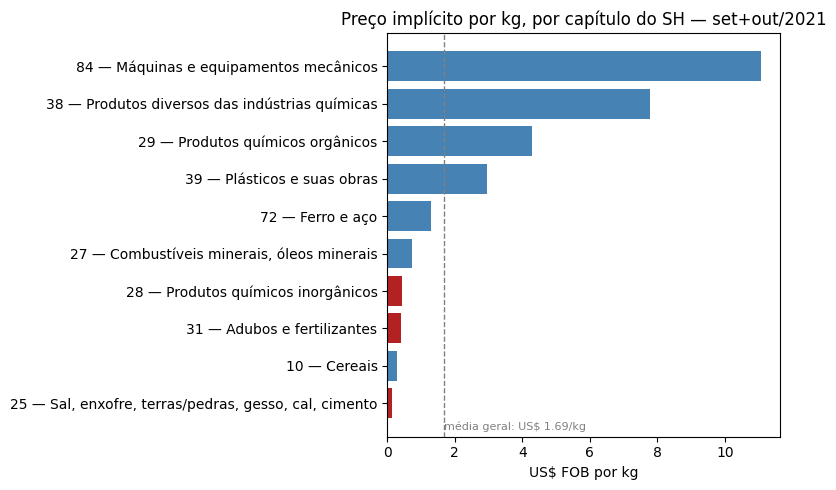

Agora sim, o número direto: o preço médio implícito da cadeia de fertilizante/insumo (capítulos 31, 25 e 28) foi de **US$ 0.38/kg**, contra **US$ 3.87/kg** no restante da pauta importada nesses dois meses — 10.3x mais caro por quilo fora da cadeia de fertilizante. Isso confirma, com dado calculado (e não só inferido pela composição do peso), que a carga que puxou o recorde de kg era mesmo de baixo valor agregado.

In [6]:
# --- preço implícito por kg (fob/kg), por capítulo do SH ---
# usa média ponderada (soma do fob dividida pela soma do kg do capítulo), não a
# média simples do fob/kg linha a linha, pra não deixar poucas linhas de baixo
# volume distorcerem o número

preco_kg_capitulo = (
    ncm_raw.groupby("capitulo")
    .apply(lambda g: g["fob"].sum() / g["kg"].sum(), include_groups=False)
    .rename("fob_por_kg")
)

capitulos_fertilizante = ["31", "25", "28"]
preco_fertilizante = (
    ncm_raw[ncm_raw["capitulo"].isin(capitulos_fertilizante)]["fob"].sum()
    / ncm_raw[ncm_raw["capitulo"].isin(capitulos_fertilizante)]["kg"].sum()
)
preco_resto = (
    ncm_raw[~ncm_raw["capitulo"].isin(capitulos_fertilizante)]["fob"].sum()
    / ncm_raw[~ncm_raw["capitulo"].isin(capitulos_fertilizante)]["kg"].sum()
)
preco_geral = ncm_raw["fob"].sum() / ncm_raw["kg"].sum()

top_preco_capitulos = preco_kg_capitulo.reindex(top_capitulos.index).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
cores = ["firebrick" if c in capitulos_fertilizante else "steelblue" for c in top_preco_capitulos.index]
labels = [f"{c} — {nomes_capitulo.get(c, 'outro')}" for c in top_preco_capitulos.index]
ax.barh(labels, top_preco_capitulos.values, color=cores)
ax.axvline(preco_geral, color="gray", linestyle="--", linewidth=1)
ax.text(preco_geral, -0.7, f"média geral: US$ {preco_geral:.2f}/kg", fontsize=8, color="gray", ha="left")
ax.set_xlabel("US$ FOB por kg")
ax.set_title("Preço implícito por kg, por capítulo do SH — set+out/2021")
plt.tight_layout()
plt.show()

display(Markdown(
    f"Agora sim, o número direto: o preço médio implícito da cadeia de fertilizante/insumo "
    f"(capítulos 31, 25 e 28) foi de **US$ {preco_fertilizante:.2f}/kg**, contra "
    f"**US$ {preco_resto:.2f}/kg** no restante da pauta importada nesses dois meses — "
    f"{preco_resto / preco_fertilizante:.1f}x mais caro por quilo fora da cadeia de fertilizante. "
    "Isso confirma, com dado calculado (e não só inferido pela composição do peso), que a carga "
    "que puxou o recorde de kg era mesmo de baixo valor agregado."
))


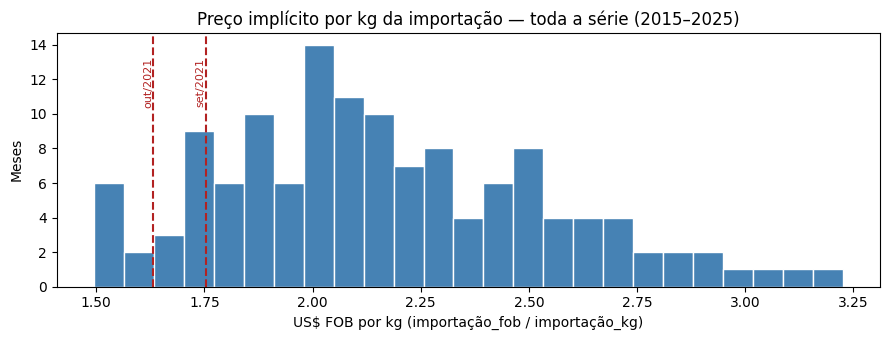

set/2021 tem o **16º** menor preço/kg de importação entre os 132 meses da série (percentil 12), e out/2021 o **8º** menor (percentil 6). Isso responde à pergunta em aberto do notebook 01: sim, o preço médio implícito por kg estava de fato entre os mais baixos de toda a série 2015–2025 nesses dois meses — não é só a composição por peso que sugere isso, o número calculado direto no painel mensal confirma.

In [7]:
# --- o fob/kg de set/out 2021 é realmente atípico frente à série histórica? ---
# usa o mesmo painel mensal do notebook 01 pra calcular o preço implícito por kg
# em TODOS os meses de 2015-2025, e ver onde set/out 2021 caem nessa distribuição

painel = pd.read_csv(
    "https://raw.githubusercontent.com/vicleme/port-of-santos-credit-fx/refs/heads/main/data/processed/painel_2015_2025.csv"
)
painel["preco_kg_importacao"] = painel["importação_fob"] / painel["importação_kg"]

alvo = painel[
    ((painel["ano"] == 2021) & (painel["mes"] == 9))
    | ((painel["ano"] == 2021) & (painel["mes"] == 10))
]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(painel["preco_kg_importacao"], bins=25, color="steelblue", edgecolor="white")
for _, linha in alvo.iterrows():
    rotulo = "set/2021" if linha["mes"] == 9 else "out/2021"
    ax.axvline(linha["preco_kg_importacao"], color="firebrick", linestyle="--", linewidth=1.5)
    ax.text(linha["preco_kg_importacao"], ax.get_ylim()[1] * 0.9, rotulo, rotation=90,
            color="firebrick", fontsize=8, ha="right", va="top")
ax.set_xlabel("US$ FOB por kg (importação_fob / importação_kg)")
ax.set_ylabel("Meses")
ax.set_title("Preço implícito por kg da importação — toda a série (2015–2025)")
plt.tight_layout()
plt.show()

percentis = painel["preco_kg_importacao"].rank(pct=True)
pct_set = percentis[alvo[alvo["mes"] == 9].index[0]] * 100
pct_out = percentis[alvo[alvo["mes"] == 10].index[0]] * 100
posicao_set = int(painel["preco_kg_importacao"].rank()[alvo[alvo["mes"] == 9].index[0]])
posicao_out = int(painel["preco_kg_importacao"].rank()[alvo[alvo["mes"] == 10].index[0]])
n_meses = len(painel)

display(Markdown(
    f"set/2021 tem o **{posicao_set}º** menor preço/kg de importação entre os {n_meses} meses da "
    f"série (percentil {pct_set:.0f}), e out/2021 o **{posicao_out}º** menor (percentil {pct_out:.0f}). "
    "Isso responde à pergunta em aberto do notebook 01: sim, o preço médio implícito por kg estava "
    "de fato entre os mais baixos de toda a série 2015–2025 nesses dois meses — não é só a "
    "composição por peso que sugere isso, o número calculado direto no painel mensal confirma."
))
